# 🌳 Heap Máxima — Fluxo Completo de Inserção e Remoção

**Lista de entrada:** `[13, 2, 6, 25, 8, 40, 1]`

Uma **heap máxima** é uma árvore binária completa onde:
- O **pai** é sempre **maior** que seus filhos
- O maior elemento fica sempre na **raiz**
- Inserção e remoção custam **O(log n)**

---
Este notebook mostra **passo a passo**:
1. Inserção de cada elemento com comparações e swaps
2. Árvore desenhada após cada operação
3. Remoção do maior elemento com reorganização

## 1. Importações

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import numpy as np

## 2. Funções de Visualização da Árvore

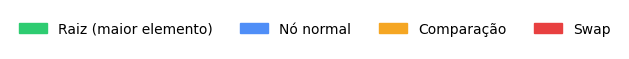

In [2]:
def posicoes_arvore(heap):
    """Calcula coordenadas (x, y) para cada nó da heap."""
    n = len(heap)
    pos = {}
    for i in range(n):
        level = int(np.floor(np.log2(i + 1)))         # nível na árvore
        nos_nivel = 2 ** level                         # nós neste nível
        pos_nivel = i - (nos_nivel - 1)               # posição dentro do nível
        largura = 2 ** (int(np.log2(n + 1)))          # largura total
        espacamento = largura / (nos_nivel + 1)
        x = espacamento * (pos_nivel + 1)
        y = -level * 1.8
        pos[i] = (x, y)
    return pos


def desenhar_heap(heap, titulo='', highlight=None, swap=None, ax=None):
    """
    Desenha a árvore da heap.
    highlight: índices a destacar em amarelo (comparação)
    swap: par (i, j) a destacar em vermelho (swap)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
        standalone = True
    else:
        standalone = False

    highlight = highlight or []
    swap = swap or []
    pos = posicoes_arvore(heap)
    n = len(heap)

    # Arestas
    for i in range(n):
        l, r = 2*i+1, 2*i+2
        for filho in [l, r]:
            if filho < n:
                xi, yi = pos[i]
                xf, yf = pos[filho]
                ax.plot([xi, xf], [yi, yf], 'k-', linewidth=1.4, zorder=1)

    # Nós
    for i in range(n):
        x, y = pos[i]
        if i in swap:
            cor = '#e84040'   # vermelho = swap
            tc  = 'white'
        elif i in highlight:
            cor = '#f5a623'   # laranja = comparação
            tc  = 'white'
        elif i == 0:
            cor = '#2ecc71'   # verde = raiz
            tc  = 'white'
        else:
            cor = '#4f8ef7'
            tc  = 'white'

        circle = plt.Circle((x, y), 0.55, color=cor, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(heap[i]), ha='center', va='center',
                fontsize=13, fontweight='bold', color=tc, zorder=3)
        # índice do nó
        ax.text(x, y - 0.75, f'[{i}]', ha='center', va='center',
                fontsize=8, color='gray', zorder=3)

    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

    # Limites automáticos
    if pos:
        xs = [p[0] for p in pos.values()]
        ys = [p[1] for p in pos.values()]
        ax.set_xlim(min(xs)-1, max(xs)+1)
        ax.set_ylim(min(ys)-1.2, max(ys)+1)

    if standalone:
        plt.tight_layout()
        plt.show()


def legenda():
    fig, ax = plt.subplots(figsize=(7, 0.7))
    patches = [
        mpatches.Patch(color='#2ecc71', label='Raiz (maior elemento)'),
        mpatches.Patch(color='#4f8ef7', label='Nó normal'),
        mpatches.Patch(color='#f5a623', label='Comparação'),
        mpatches.Patch(color='#e84040', label='Swap'),
    ]
    ax.legend(handles=patches, loc='center', ncol=4, fontsize=10, frameon=False)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

legenda()

## 3. Implementação da Heap Máxima com Log Detalhado

In [3]:
class MaxHeapVisual:
    def __init__(self):
        self.heap = []
        self.total_comparacoes = 0
        self.total_swaps = 0

    def inserir(self, valor):
        print(f"\n{'='*55}")
        print(f"  ➕ INSERINDO: {valor}")
        print(f"{'='*55}")

        self.heap.append(valor)
        idx = len(self.heap) - 1
        print(f"  → Adicionado na posição [{idx}]")
        print(f"  → Heap: {self.heap}")

        # Desenha após inserção simples
        desenhar_heap(self.heap[:],
                      titulo=f'Após inserir {valor} (antes do sift-up)',
                      highlight=[idx])

        self._sift_up(idx)

    def _sift_up(self, idx):
        """Sobe o elemento até satisfazer a propriedade de heap máxima."""
        while idx > 0:
            pai = (idx - 1) // 2
            self.total_comparacoes += 1
            print(f"  🔍 Comparando: heap[{idx}]={self.heap[idx]} com pai heap[{pai}]={self.heap[pai]}")

            if self.heap[idx] > self.heap[pai]:
                print(f"  🔁 SWAP: {self.heap[idx]} ↔ {self.heap[pai]}")
                self.total_swaps += 1

                # Mostra o swap
                desenhar_heap(self.heap[:],
                              titulo=f'Swap: {self.heap[idx]} ↔ {self.heap[pai]}',
                              swap=[idx, pai])

                self.heap[idx], self.heap[pai] = self.heap[pai], self.heap[idx]
                idx = pai

                print(f"  → Heap: {self.heap}")
                desenhar_heap(self.heap[:],
                              titulo=f'Após swap — Heap: {self.heap}',
                              highlight=[idx])
            else:
                print(f"  ✅ Propriedade satisfeita. Elemento na posição correta.")
                break

        print(f"  ✔ Heap final após inserção: {self.heap}")

    def remover_max(self):
        if not self.heap:
            print("Heap vazia!")
            return None

        print(f"\n{'='*55}")
        print(f"  ❌ REMOVENDO RAIZ (máximo): {self.heap[0]}")
        print(f"{'='*55}")

        removido = self.heap[0]

        # Move o último para a raiz
        ultimo = self.heap.pop()
        if self.heap:
            self.heap[0] = ultimo
            print(f"  → Último elemento ({ultimo}) movido para a raiz")
            print(f"  → Heap: {self.heap}")
            desenhar_heap(self.heap[:],
                          titulo=f'Removido {removido} — {ultimo} colocado na raiz',
                          highlight=[0])
            self._sift_down(0)
        else:
            print("  → Heap ficou vazia.")

        print(f"  ✔ Elemento removido: {removido}")
        return removido

    def _sift_down(self, idx):
        """Desce o elemento até satisfazer a propriedade de heap máxima."""
        n = len(self.heap)
        while True:
            maior = idx
            l, r = 2*idx+1, 2*idx+2

            if l < n:
                self.total_comparacoes += 1
                print(f"  🔍 Comparando: heap[{idx}]={self.heap[idx]} com filho esq heap[{l}]={self.heap[l]}")
                if self.heap[l] > self.heap[maior]:
                    maior = l

            if r < n:
                self.total_comparacoes += 1
                print(f"  🔍 Comparando: heap[{maior}]={self.heap[maior]} com filho dir heap[{r}]={self.heap[r]}")
                if self.heap[r] > self.heap[maior]:
                    maior = r

            if maior != idx:
                print(f"  🔁 SWAP: {self.heap[idx]} ↔ {self.heap[maior]}")
                self.total_swaps += 1
                desenhar_heap(self.heap[:],
                              titulo=f'Swap: {self.heap[idx]} ↔ {self.heap[maior]}',
                              swap=[idx, maior])
                self.heap[idx], self.heap[maior] = self.heap[maior], self.heap[idx]
                print(f"  → Heap: {self.heap}")
                desenhar_heap(self.heap[:],
                              titulo=f'Após swap — Heap: {self.heap}',
                              highlight=[maior])
                idx = maior
            else:
                print(f"  ✅ Propriedade satisfeita. Sift-down encerrado.")
                break

        print(f"  ✔ Heap após remoção: {self.heap}")

    def estatisticas(self):
        print(f"\n{'='*55}")
        print(f"  📊 ESTATÍSTICAS GERAIS")
        print(f"{'='*55}")
        print(f"  Total de comparações : {self.total_comparacoes}")
        print(f"  Total de swaps       : {self.total_swaps}")
        print(f"  Heap final           : {self.heap}")

print("✅ Classe MaxHeapVisual definida!")

✅ Classe MaxHeapVisual definida!


## 4. ➕ Inserção dos Elementos


  ➕ INSERINDO: 13
  → Adicionado na posição [0]
  → Heap: [13]


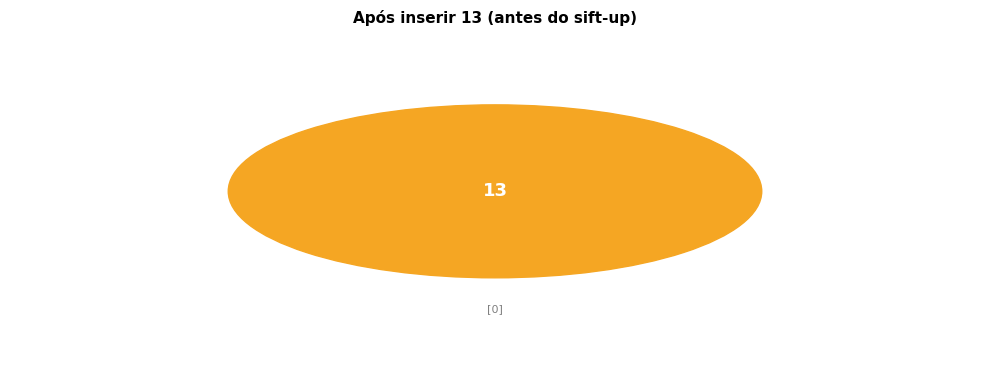

  ✔ Heap final após inserção: [13]

  ➕ INSERINDO: 2
  → Adicionado na posição [1]
  → Heap: [13, 2]


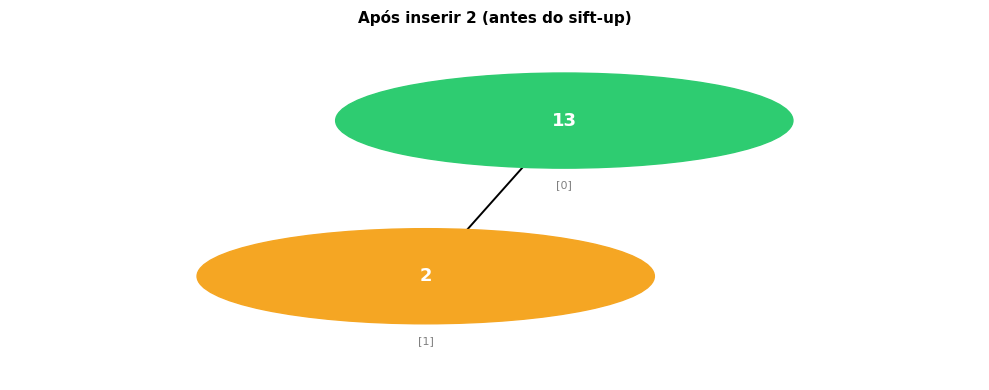

  🔍 Comparando: heap[1]=2 com pai heap[0]=13
  ✅ Propriedade satisfeita. Elemento na posição correta.
  ✔ Heap final após inserção: [13, 2]

  ➕ INSERINDO: 6
  → Adicionado na posição [2]
  → Heap: [13, 2, 6]


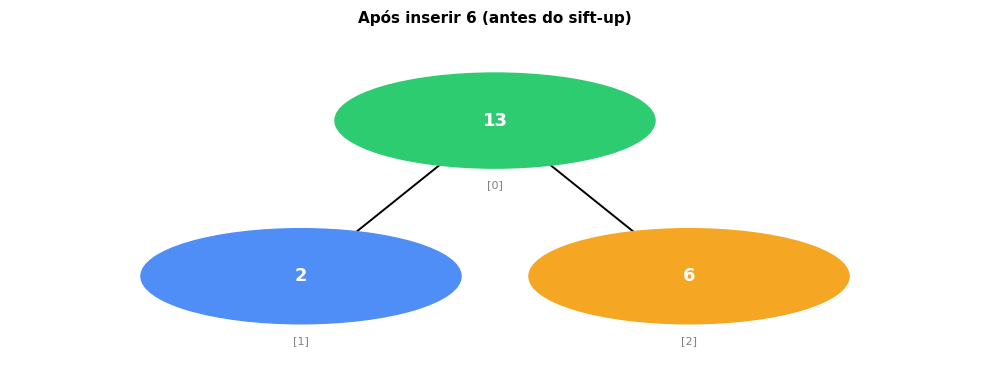

  🔍 Comparando: heap[2]=6 com pai heap[0]=13
  ✅ Propriedade satisfeita. Elemento na posição correta.
  ✔ Heap final após inserção: [13, 2, 6]

  ➕ INSERINDO: 25
  → Adicionado na posição [3]
  → Heap: [13, 2, 6, 25]


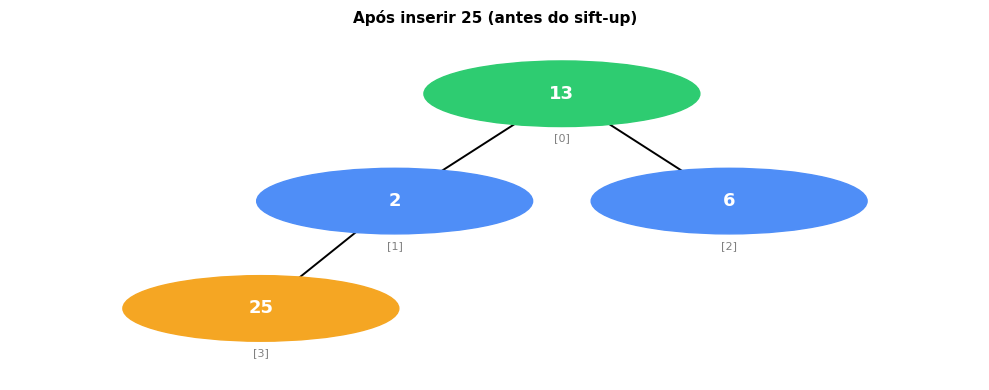

  🔍 Comparando: heap[3]=25 com pai heap[1]=2
  🔁 SWAP: 25 ↔ 2


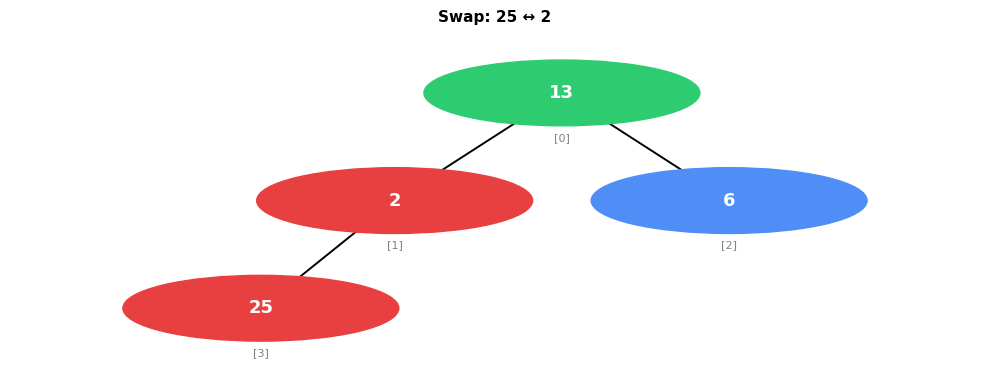

  → Heap: [13, 25, 6, 2]


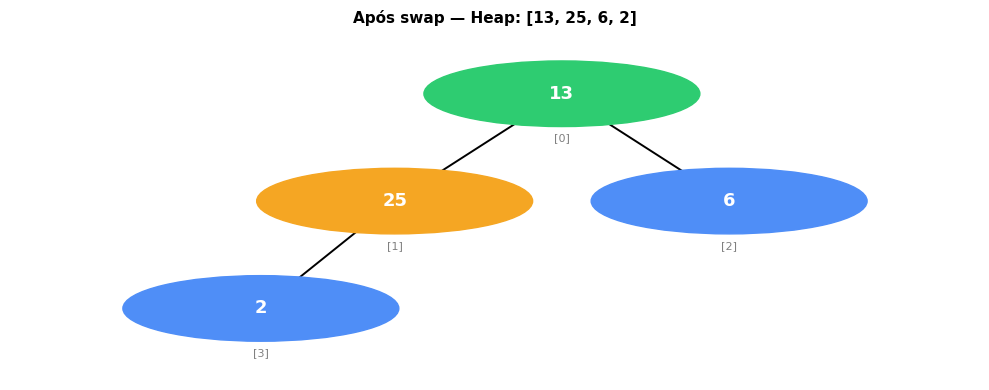

  🔍 Comparando: heap[1]=25 com pai heap[0]=13
  🔁 SWAP: 25 ↔ 13


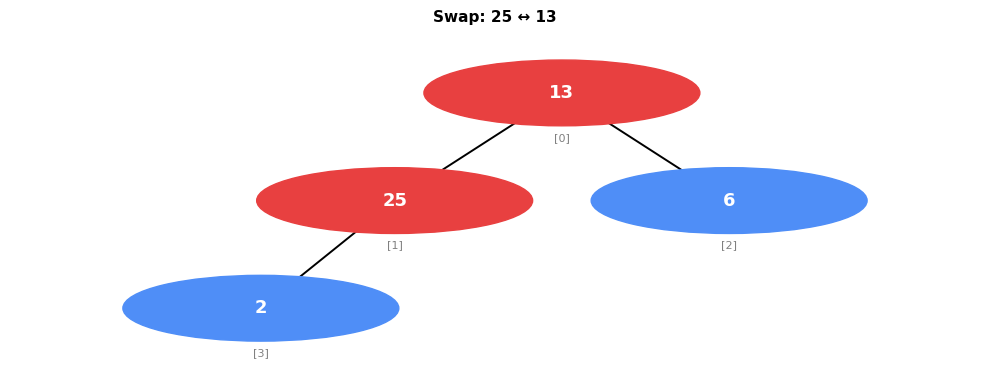

  → Heap: [25, 13, 6, 2]


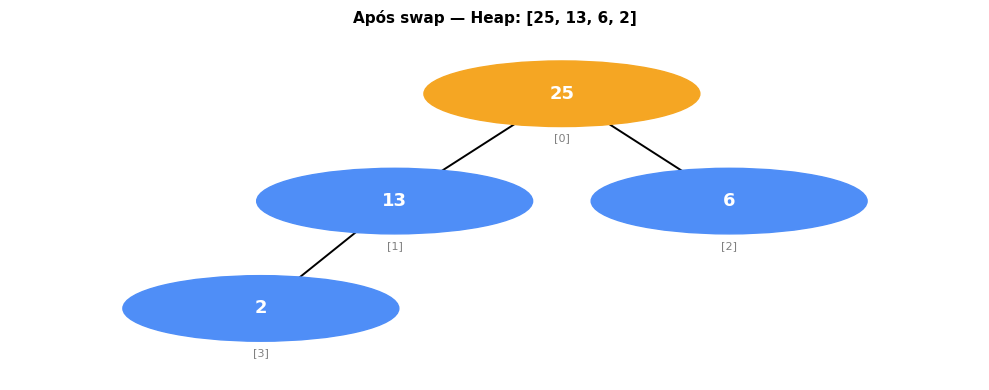

  ✔ Heap final após inserção: [25, 13, 6, 2]

  ➕ INSERINDO: 8
  → Adicionado na posição [4]
  → Heap: [25, 13, 6, 2, 8]


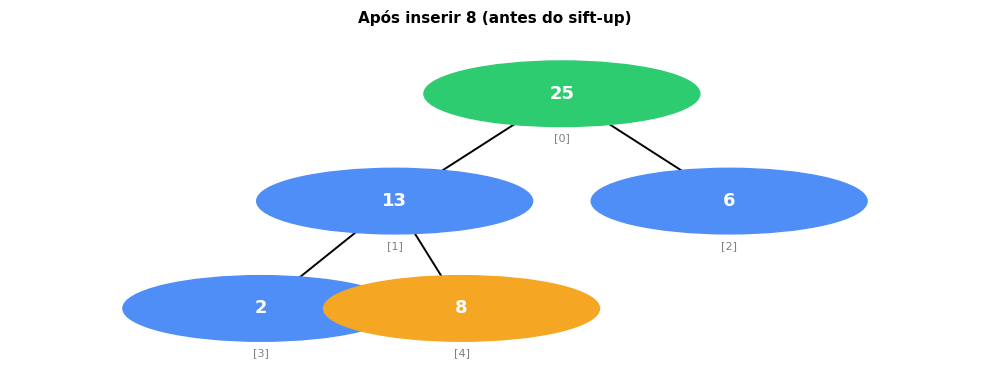

  🔍 Comparando: heap[4]=8 com pai heap[1]=13
  ✅ Propriedade satisfeita. Elemento na posição correta.
  ✔ Heap final após inserção: [25, 13, 6, 2, 8]

  ➕ INSERINDO: 40
  → Adicionado na posição [5]
  → Heap: [25, 13, 6, 2, 8, 40]


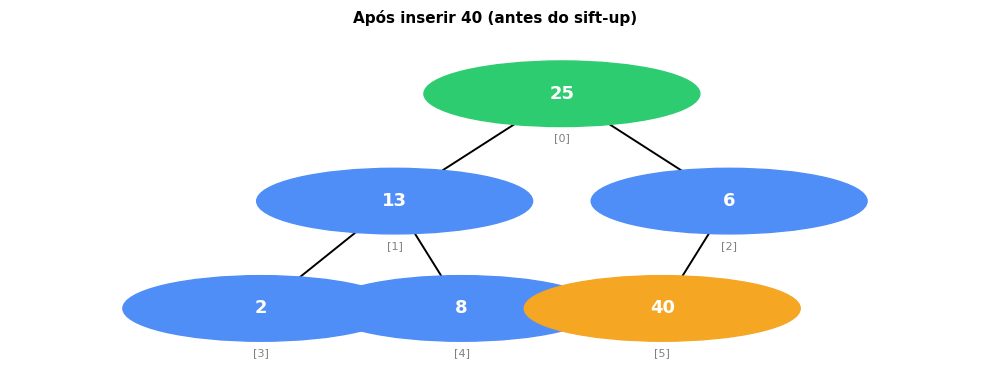

  🔍 Comparando: heap[5]=40 com pai heap[2]=6
  🔁 SWAP: 40 ↔ 6


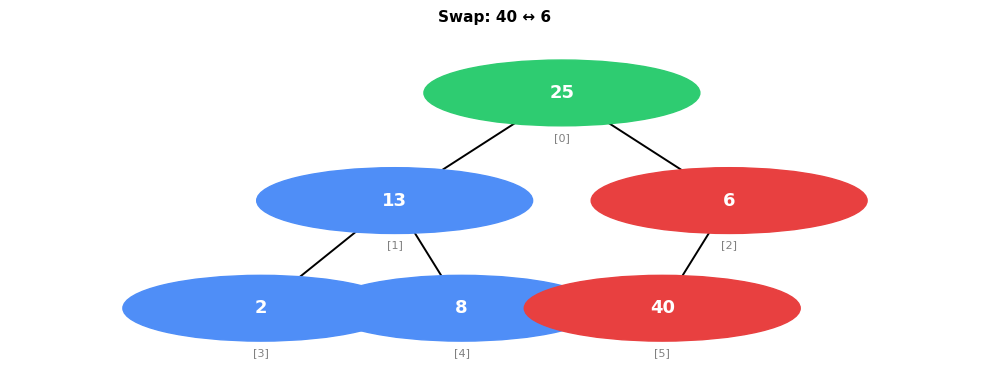

  → Heap: [25, 13, 40, 2, 8, 6]


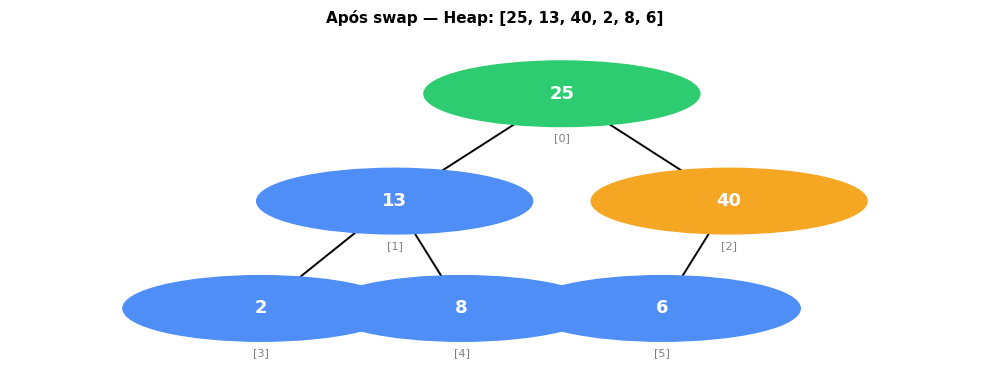

  🔍 Comparando: heap[2]=40 com pai heap[0]=25
  🔁 SWAP: 40 ↔ 25


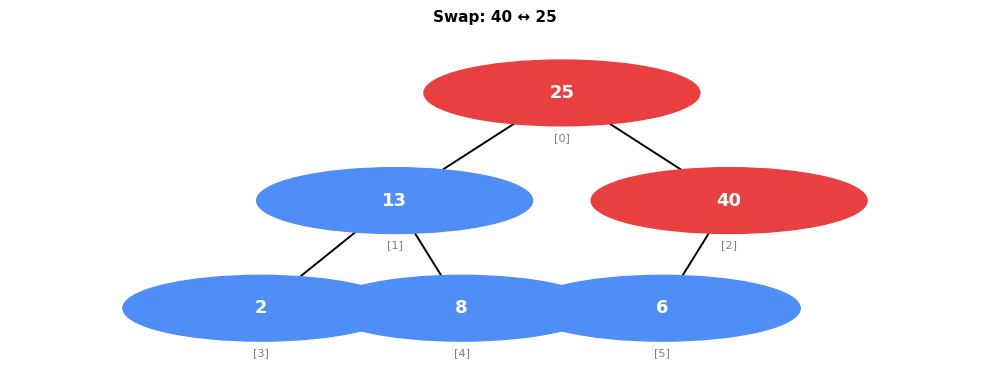

  → Heap: [40, 13, 25, 2, 8, 6]


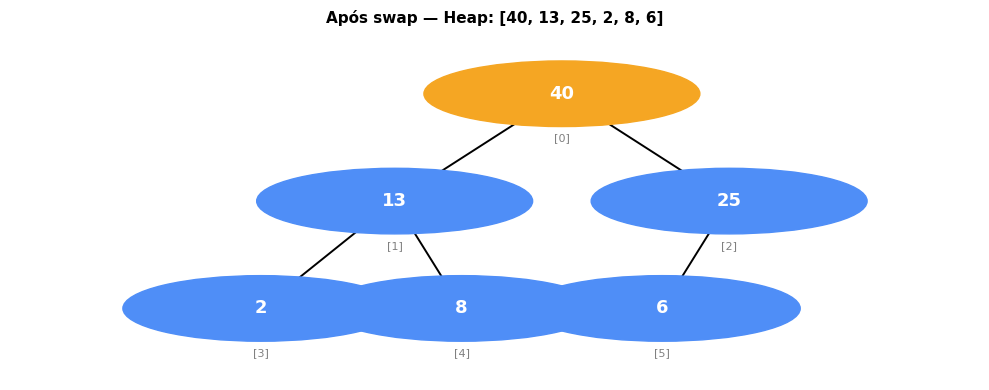

  ✔ Heap final após inserção: [40, 13, 25, 2, 8, 6]

  ➕ INSERINDO: 1
  → Adicionado na posição [6]
  → Heap: [40, 13, 25, 2, 8, 6, 1]


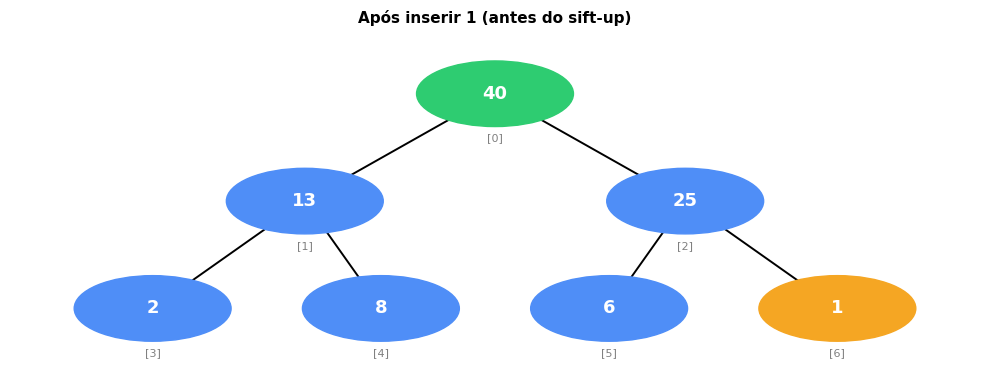

  🔍 Comparando: heap[6]=1 com pai heap[2]=25
  ✅ Propriedade satisfeita. Elemento na posição correta.
  ✔ Heap final após inserção: [40, 13, 25, 2, 8, 6, 1]


In [4]:
elementos = [13, 2, 6, 25, 8, 40, 1]
h = MaxHeapVisual()

for el in elementos:
    h.inserir(el)

## 5. Estado Final Após Todas as Inserções

Heap como array: [40, 13, 25, 2, 8, 6, 1]

Mapeamento índice → valor:
  [0] = 40  |  pai: -  |  filho_esq: 1  |  filho_dir: 2
  [1] = 13  |  pai: 0  |  filho_esq: 3  |  filho_dir: 4
  [2] = 25  |  pai: 0  |  filho_esq: 5  |  filho_dir: 6
  [3] =  2  |  pai: 1  |  filho_esq: -  |  filho_dir: -
  [4] =  8  |  pai: 1  |  filho_esq: -  |  filho_dir: -
  [5] =  6  |  pai: 2  |  filho_esq: -  |  filho_dir: -
  [6] =  1  |  pai: 2  |  filho_esq: -  |  filho_dir: -


/tmp/ipykernel_15171/2583142026.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


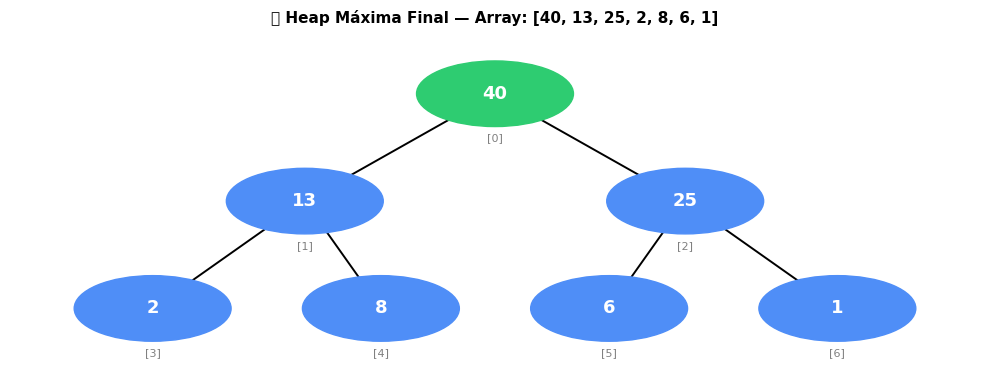

In [5]:
print(f"Heap como array: {h.heap}")
print("\nMapeamento índice → valor:")
for i, v in enumerate(h.heap):
    pai = (i-1)//2 if i > 0 else '-'
    l = 2*i+1 if 2*i+1 < len(h.heap) else '-'
    r = 2*i+2 if 2*i+2 < len(h.heap) else '-'
    print(f"  [{i}] = {v:>2}  |  pai: {pai}  |  filho_esq: {l}  |  filho_dir: {r}")

desenhar_heap(h.heap, titulo=f'✅ Heap Máxima Final — Array: {h.heap}')

## 6. ❌ Remoção dos Elementos (do maior para o menor)


  ❌ REMOVENDO RAIZ (máximo): 40
  → Último elemento (1) movido para a raiz
  → Heap: [1, 13, 25, 2, 8, 6]


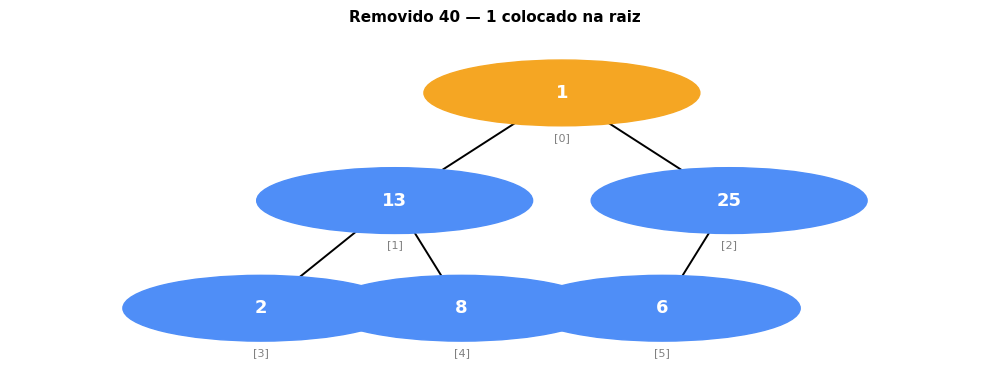

  🔍 Comparando: heap[0]=1 com filho esq heap[1]=13
  🔍 Comparando: heap[1]=13 com filho dir heap[2]=25
  🔁 SWAP: 1 ↔ 25


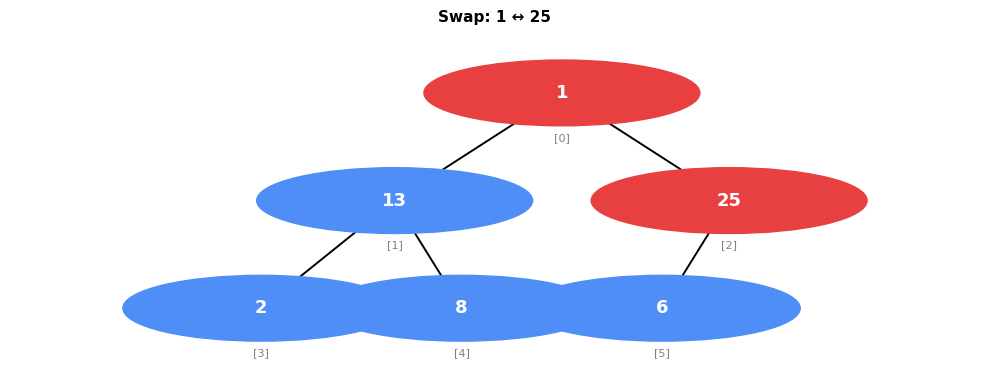

  → Heap: [25, 13, 1, 2, 8, 6]


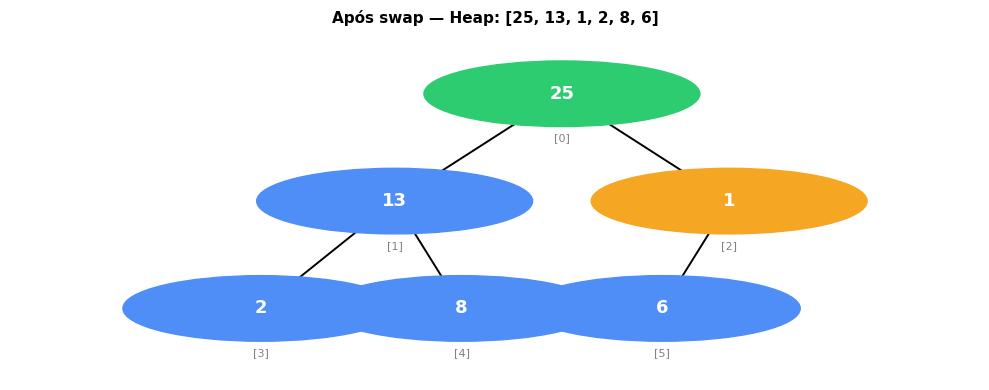

  🔍 Comparando: heap[2]=1 com filho esq heap[5]=6
  🔁 SWAP: 1 ↔ 6


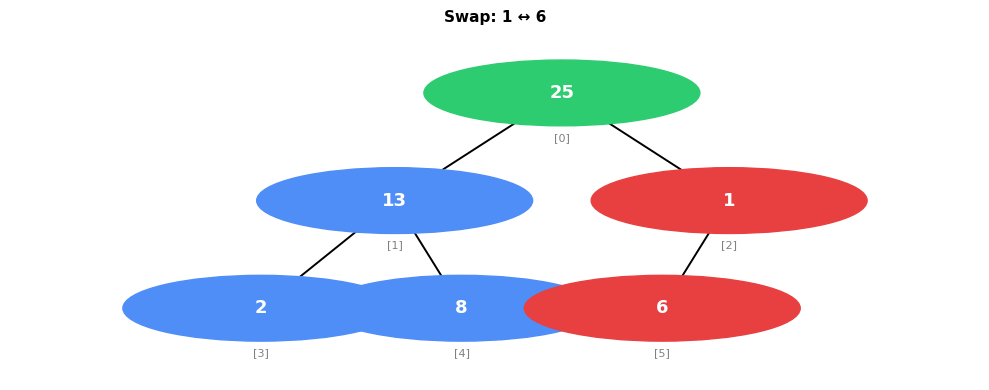

  → Heap: [25, 13, 6, 2, 8, 1]


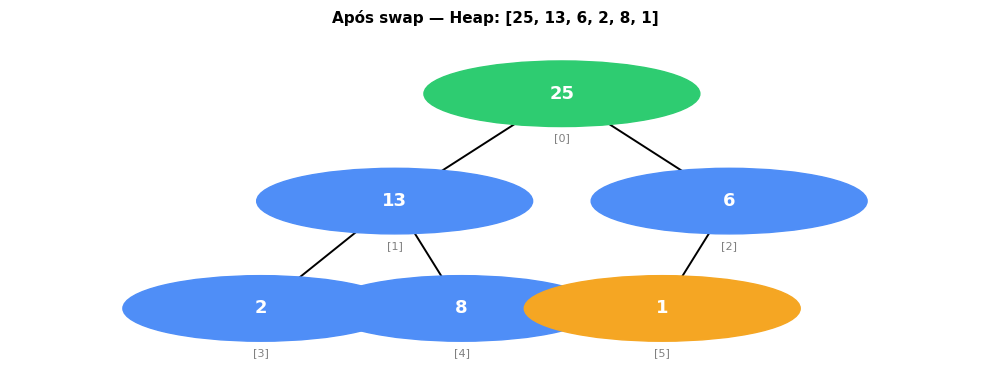

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [25, 13, 6, 2, 8, 1]
  ✔ Elemento removido: 40

  ❌ REMOVENDO RAIZ (máximo): 25
  → Último elemento (1) movido para a raiz
  → Heap: [1, 13, 6, 2, 8]


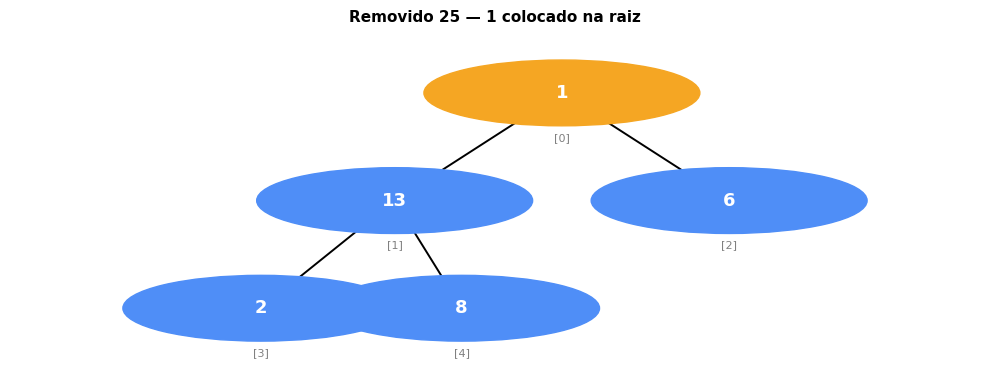

  🔍 Comparando: heap[0]=1 com filho esq heap[1]=13
  🔍 Comparando: heap[1]=13 com filho dir heap[2]=6
  🔁 SWAP: 1 ↔ 13


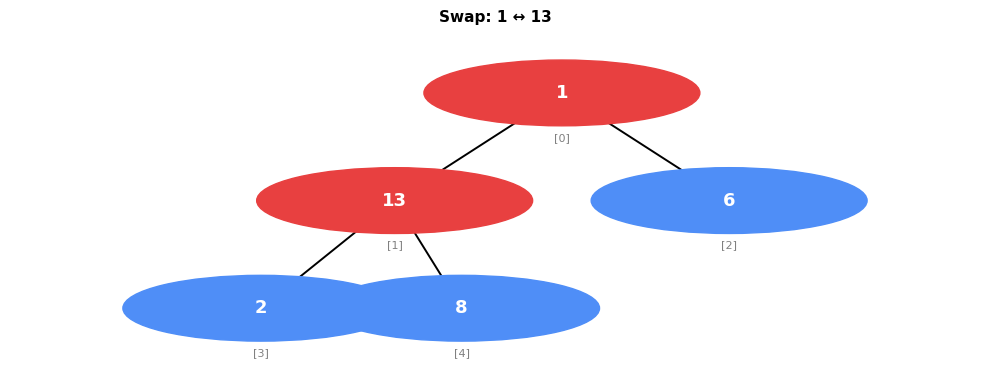

  → Heap: [13, 1, 6, 2, 8]


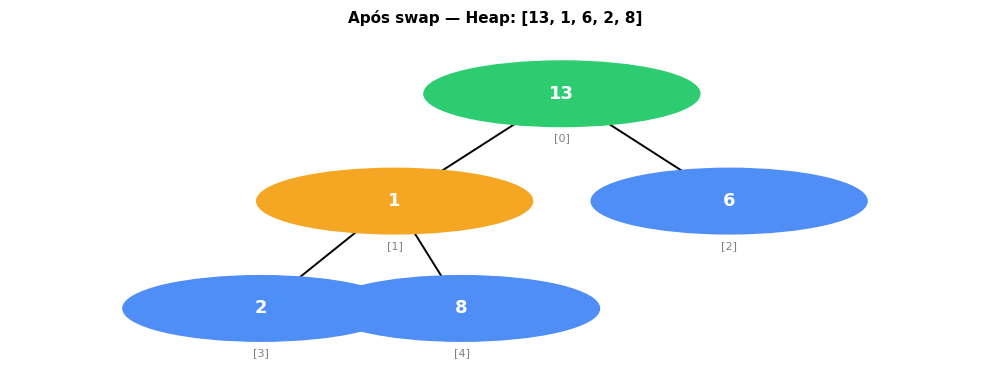

  🔍 Comparando: heap[1]=1 com filho esq heap[3]=2
  🔍 Comparando: heap[3]=2 com filho dir heap[4]=8
  🔁 SWAP: 1 ↔ 8


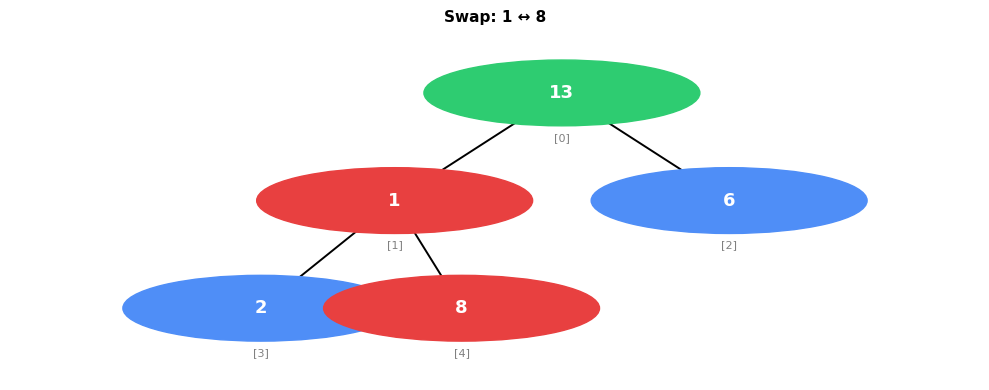

  → Heap: [13, 8, 6, 2, 1]


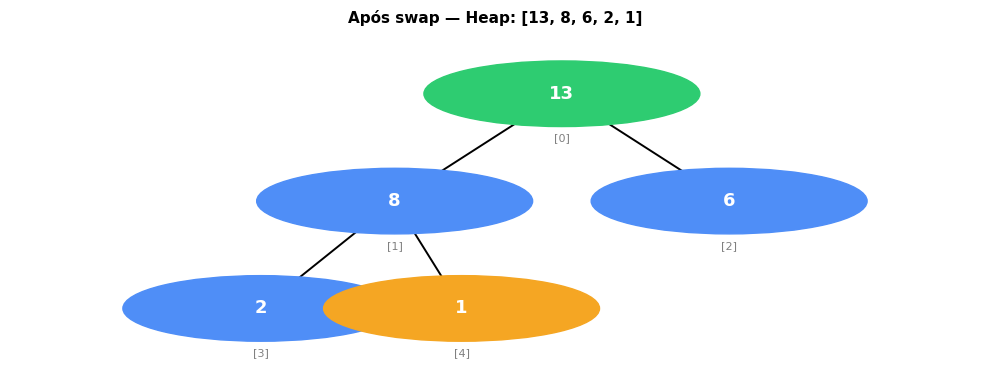

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [13, 8, 6, 2, 1]
  ✔ Elemento removido: 25

  ❌ REMOVENDO RAIZ (máximo): 13
  → Último elemento (1) movido para a raiz
  → Heap: [1, 8, 6, 2]


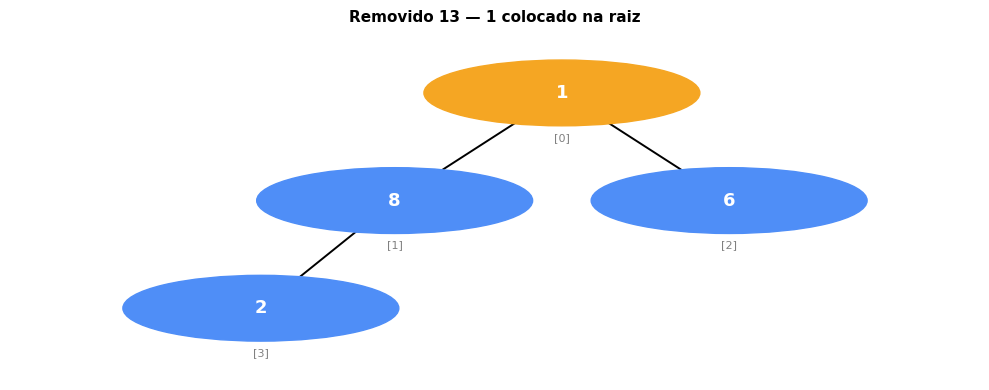

  🔍 Comparando: heap[0]=1 com filho esq heap[1]=8
  🔍 Comparando: heap[1]=8 com filho dir heap[2]=6
  🔁 SWAP: 1 ↔ 8


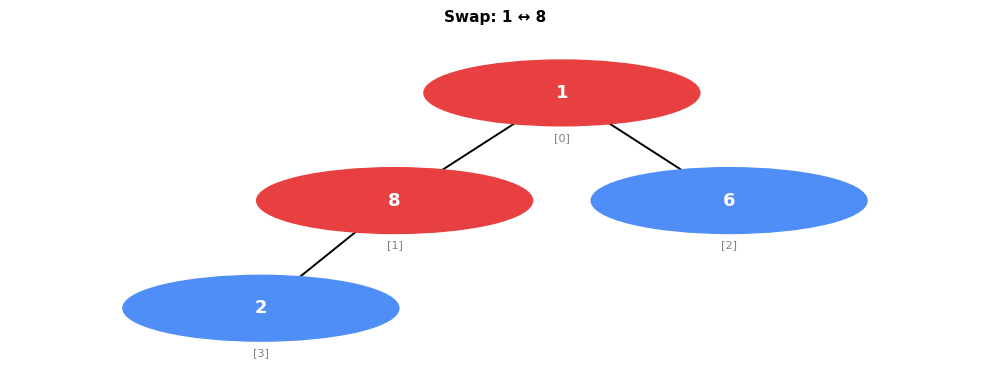

  → Heap: [8, 1, 6, 2]


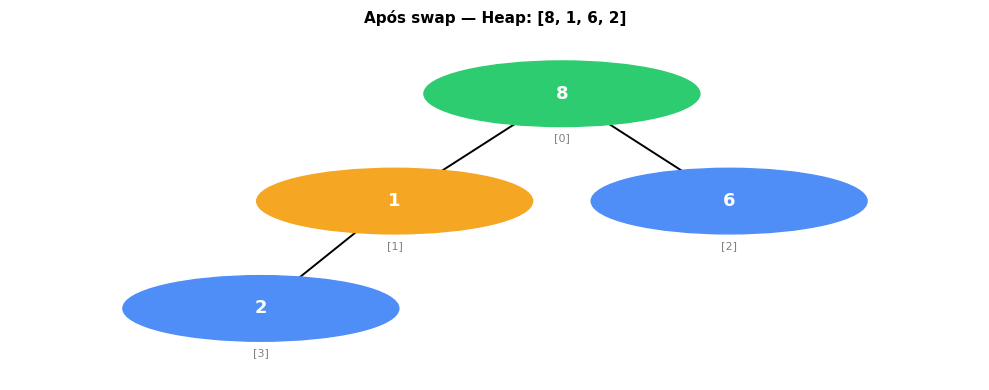

  🔍 Comparando: heap[1]=1 com filho esq heap[3]=2
  🔁 SWAP: 1 ↔ 2


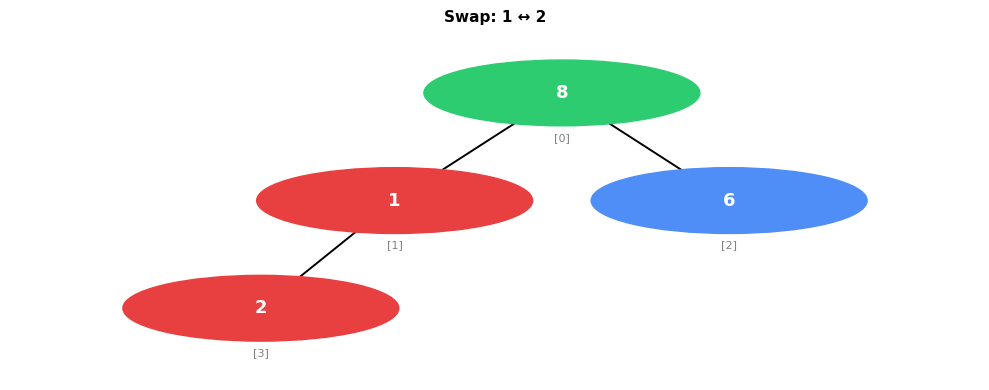

  → Heap: [8, 2, 6, 1]


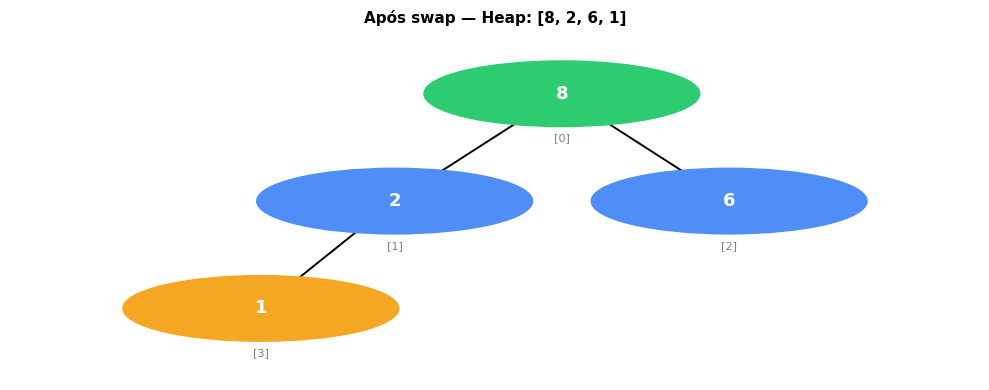

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [8, 2, 6, 1]
  ✔ Elemento removido: 13

  ❌ REMOVENDO RAIZ (máximo): 8
  → Último elemento (1) movido para a raiz
  → Heap: [1, 2, 6]


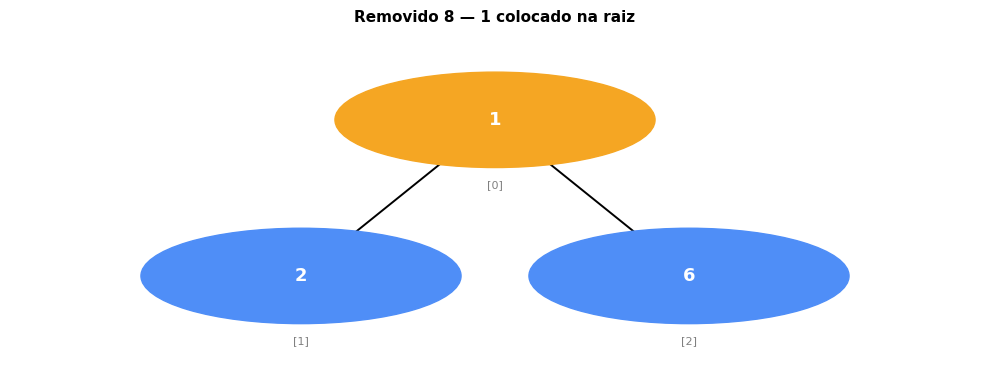

  🔍 Comparando: heap[0]=1 com filho esq heap[1]=2
  🔍 Comparando: heap[1]=2 com filho dir heap[2]=6
  🔁 SWAP: 1 ↔ 6


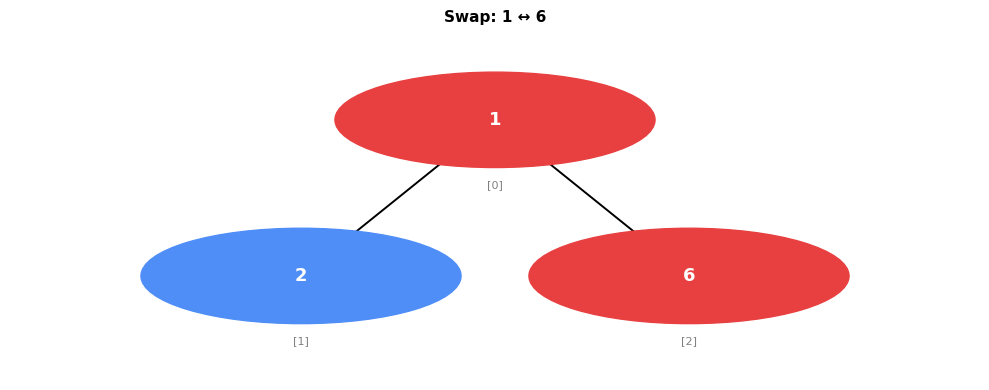

  → Heap: [6, 2, 1]


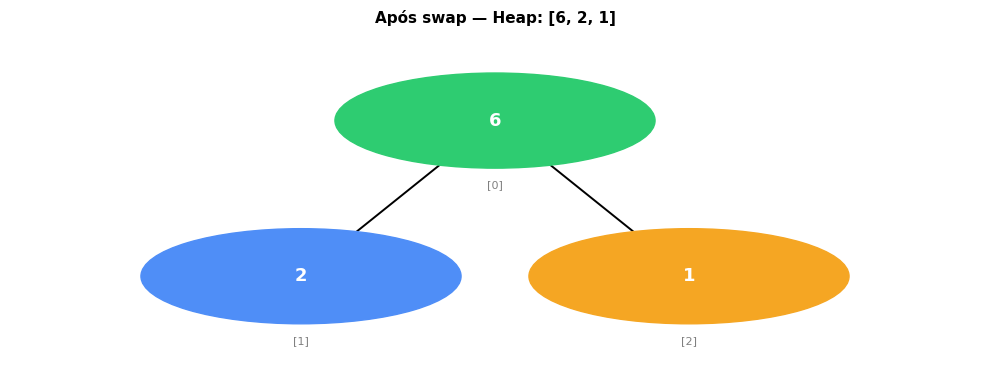

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [6, 2, 1]
  ✔ Elemento removido: 8

  ❌ REMOVENDO RAIZ (máximo): 6
  → Último elemento (1) movido para a raiz
  → Heap: [1, 2]


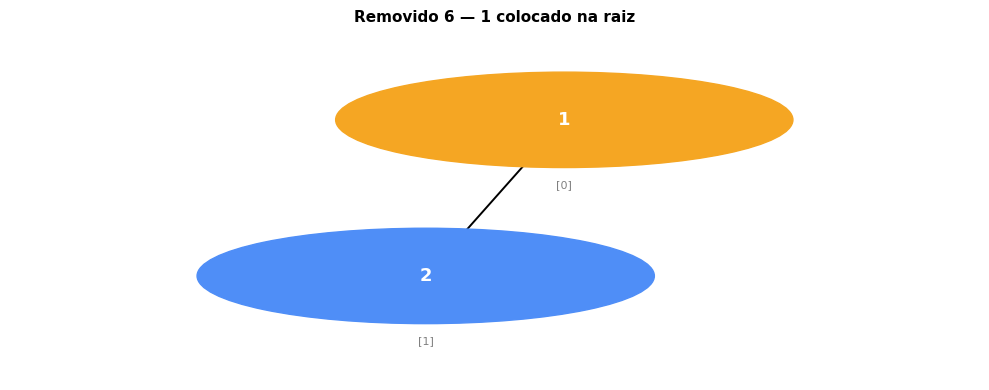

  🔍 Comparando: heap[0]=1 com filho esq heap[1]=2
  🔁 SWAP: 1 ↔ 2


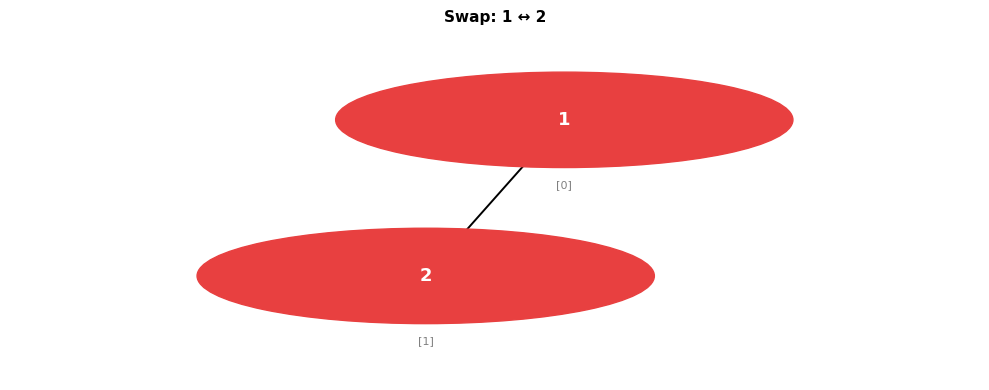

  → Heap: [2, 1]


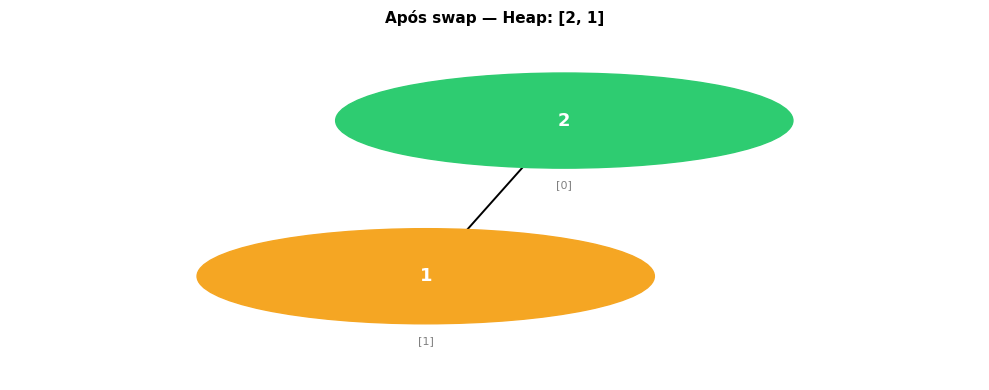

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [2, 1]
  ✔ Elemento removido: 6

  ❌ REMOVENDO RAIZ (máximo): 2
  → Último elemento (1) movido para a raiz
  → Heap: [1]


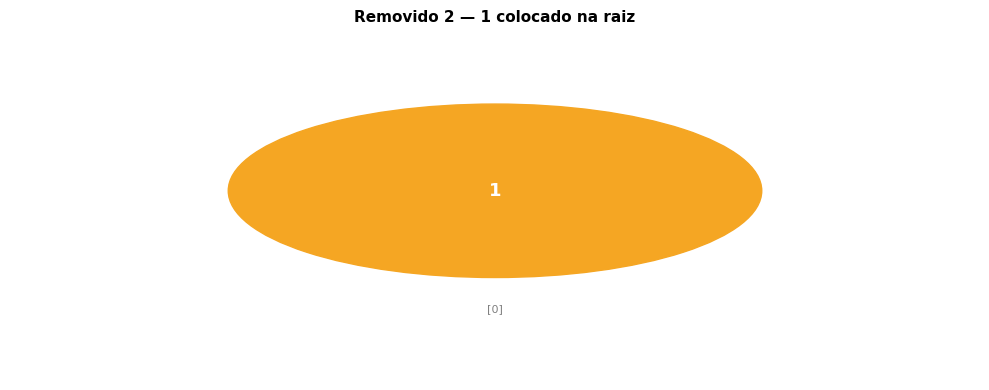

  ✅ Propriedade satisfeita. Sift-down encerrado.
  ✔ Heap após remoção: [1]
  ✔ Elemento removido: 2

  ❌ REMOVENDO RAIZ (máximo): 1
  → Heap ficou vazia.
  ✔ Elemento removido: 1

🎯 Ordem de saída (heap sort): [40, 25, 13, 8, 6, 2, 1]


In [6]:
ordem_remocao = []

while h.heap:
    removido = h.remover_max()
    ordem_remocao.append(removido)

print(f"\n🎯 Ordem de saída (heap sort): {ordem_remocao}")

## 7. 📊 Estatísticas e Resumo

In [7]:
h.estatisticas()

print(f"\n🎯 Ordem de remoção (maior → menor): {ordem_remocao}")
print(f"   (equivalente ao Heap Sort em ordem decrescente)")


  📊 ESTATÍSTICAS GERAIS
  Total de comparações : 21
  Total de swaps       : 12
  Heap final           : []

🎯 Ordem de remoção (maior → menor): [40, 25, 13, 8, 6, 2, 1]
   (equivalente ao Heap Sort em ordem decrescente)


## 8. Resumo Visual — Linha do Tempo da Heap

/tmp/ipykernel_15171/2355397063.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


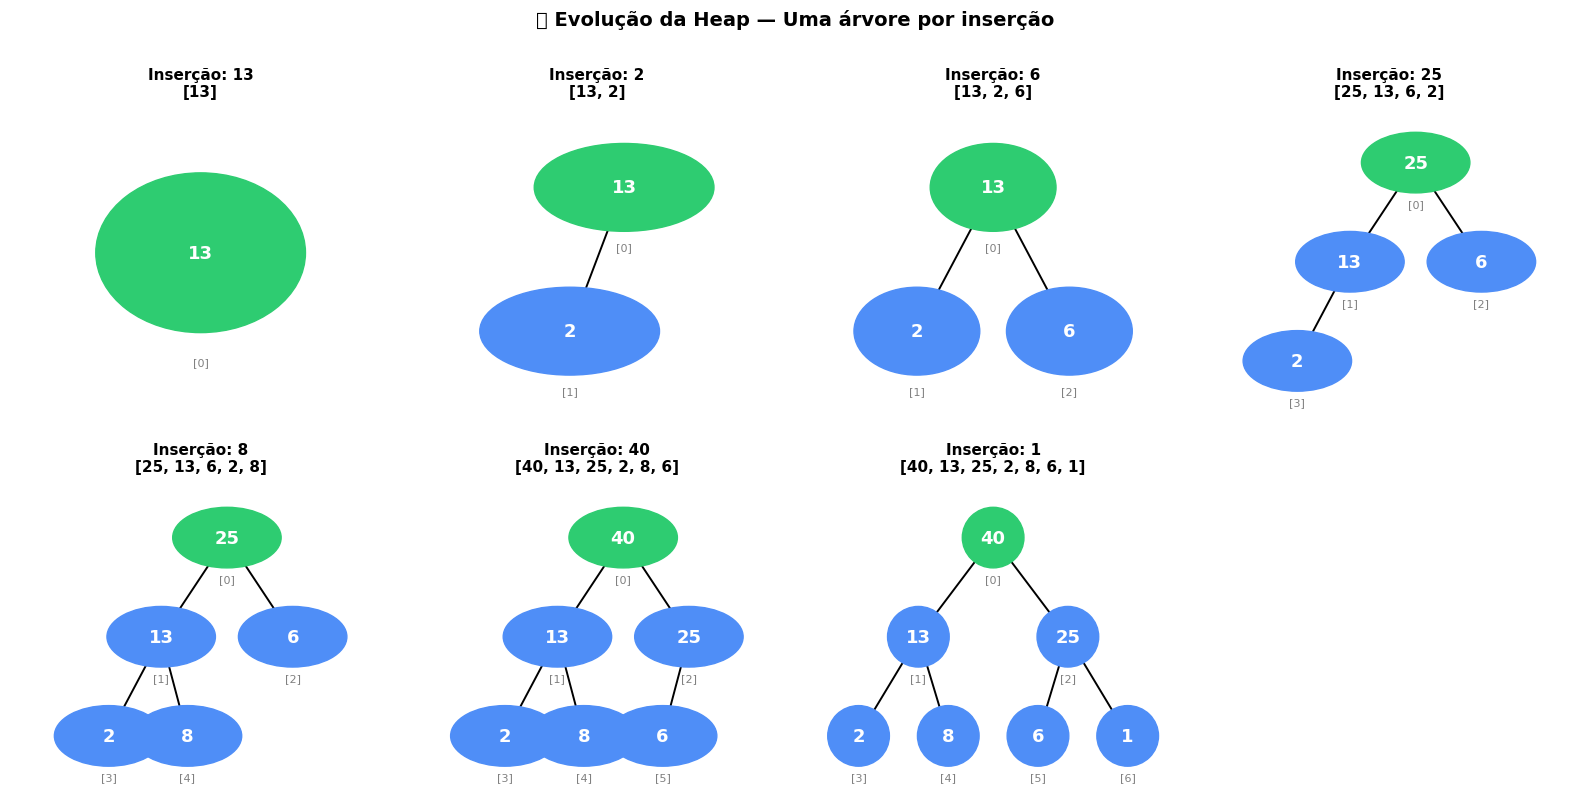

In [8]:
# Reconstrói a heap para capturar estados pós cada inserção
estados = []
heap_tmp = []

def sift_up_simples(heap, idx):
    while idx > 0:
        pai = (idx - 1) // 2
        if heap[idx] > heap[pai]:
            heap[idx], heap[pai] = heap[pai], heap[idx]
            idx = pai
        else:
            break

for el in elementos:
    heap_tmp.append(el)
    sift_up_simples(heap_tmp, len(heap_tmp)-1)
    estados.append((f'Inserção: {el}\n{heap_tmp[:]}'  , heap_tmp[:]))

n_estados = len(estados)
cols = 4
rows = (n_estados + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, (titulo, estado) in enumerate(estados):
    desenhar_heap(estado, titulo=titulo, ax=axes[i])

# Oculta eixos extras
for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle('📈 Evolução da Heap — Uma árvore por inserção', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Propriedades da Heap Máxima — Recapitulando

| Operação | Complexidade |
|---|---|
| Inserção | O(log n) |
| Remoção do máximo | O(log n) |
| Consulta do máximo | O(1) |
| Construção (n inserções) | O(n log n) |

**Regras da heap máxima:**
- `heap[pai] >= heap[filho]` para todo nó
- Índice do pai de `i`: `(i-1) // 2`
- Índice do filho esquerdo de `i`: `2*i + 1`
- Índice do filho direito de `i`: `2*i + 2`

> A remoção repetida do máximo produz os elementos em **ordem decrescente** — é o princípio do **Heap Sort**.